In [1]:
%pip install torch torchvision torchaudio

import torch
import sys, os

from multiprocessing import Queue, Process
from torch.utils.data import ConcatDataset
from lib_train import *
from lib_cnn import * 
from lib_IGviz import *
from lib_influence_groundtruth import *
from main_vision_label_noise import *


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# -------------- Device Setup --------------
DEVICE = torch.device('cpu')
if not torch.cuda.is_available():
    print("WARN: Cuda unavailable, defaulting to cpu...")
print(f"Using device: {DEVICE}")


# -------------- Initialize arguments --------------
dataset       = 'Flowers102'
model_name    = 'ShallowMNIST'
root_folder   = '../data'
program_mode  = 'normal' # normal or GT (Ground truth)
save_mode     = 'store' # store, load or none
visualize     = False
noise_type    = 'symmetric'
noise_level   = 0
num_workers   = 0
log_verbosity = 1

# -------------- Start logger queue and listener process --------------
log_queue = Queue()
listener = Process(target=log_listener, args=(log_queue, 1))
listener.start()

logger = InfluenceLogger(log_queue, verbose=log_verbosity)
logger.log("Main process started.", level=1)


labelnoise_params = {
    'noise_type':  noise_type,
    'noise_level': noise_level
}
loader_params = {
    'dataset_name':     dataset,
    'conversion':       'none',
    'root_folder':      root_folder,
    'training_size':    'full', # 'full'
    'batch_size':       20,   # 20-40
    'IG_batch_size':    400, 
    'transform':        None,
    'add_singleton':    False,
    'convert_to_torch': False,
    'num_workers':      num_workers,
}
influence_params = {
    'loss_scaling_span':  'full', # 'batch' or 'full'
    'loss_scaling_type':  'root_mean_squared', # 'mean' or 'mean_absolute' or None
    'set_zero_mean':      False,# 'full' or 'separate'
    'class_normalize' :   False, 
    'remove_negatives' :  False, 
    'clipping' :          False,
    'intraclass_only' :   True,
    'negative_clipping':  False,
    'clip_outliers':      False,
    'mode':               'mean', # For InfluenceGraphv3
    'gradient_lr':        0.1, # For InfluenceGraphv3
    'dtype':              np.float32,
    'graph_type':         InfluenceGraphv4,
}
train_params = {
    'optimizer':           'Adam',
    'scheduler':           {'name': None}, # 'step_size': 10, 'milestones':[10,20,30],'gamma':0.8, 'max_lr': 0.01}
    'init_rate':           0.0005,
    'total_epochs':        100,
    'weight_decay':        0, 
    'criterion':           'CrossEntropyLoss',
    'disp_epoch':          False,
    'disp_loss_epoch':     False,
    'disp_time_per_epoch': True, 
    'disp_loss_final':     True, 
    'disp_accuracy_final': True
}
influence_GT_params = {
    'type':                'batch', # batch or representative
    'training_iterations': train_params['total_epochs'],
    'intraclass_only':     True,
    'dtype':               np.float32,
}
influence_GT_train_params = {
    'optimizer':           'SGD',
    'scheduler':           {'name': None}, # 'step_size': 10, 'milestones':[10,20,30],'gamma':0.8, 'max_lr': 0.01}
    'init_rate':           0.1,
    'total_epochs':        50,
    'weight_decay':        0, 
    'criterion':           'CrossEntropyLoss',
    'disp_epoch':          False,
    'disp_loss_epoch':     True,
    'disp_time_per_batch': True,
    'disp_total_time':     True,
}
model_params = {
    'type':                CNN,
    'name':                model_name,
    'in_channels':         1,
    'num_classes':         10,
    'batchnorm':           True,
}

# -------------- Customize arguments based on model --------------
if dataset == 'MNIST' or dataset == 'FashionMNIST':
    model_params['name']        = 'ShallowMNIST'
    model_params['in_channels'] = 1
    model_params['num_classes'] = 10

elif dataset == 'CIFAR10':
    model_params['name']        = 'ShallowCIFAR10'
    model_params['in_channels'] = 3
    model_params['num_classes'] = 10

elif dataset == 'Flowers102':
    model_params['name']        = 'ShallowCIFAR10'
    model_params['in_channels'] = 3
    model_params['num_classes'] = 102


model = model_params['type'](
    model_params['name'],
    in_channels = model_params['in_channels'],
    num_classes = model_params['num_classes'],
    batchnorm = model_params['batchnorm']
)

WARN: Cuda unavailable, defaulting to cpu...
Using device: cpu
[2025-07-12 20:00:40] (+0.00s) [PID 47311] [MainProcess] Main process started.


In [3]:
def genloaders_vision_test(loader_params, labelnoise_params, image_size=(224, 224)):

    def preprocess_dataset(dataset, is_grayscale=False):
        if isinstance(dataset.data, np.ndarray):
            data = torch.from_numpy(dataset.data)
        else:
            data = dataset.data  # Already a torch.Tensor

        data = data.float() / 255.0

        if is_grayscale:
            data = data.unsqueeze(1)  # Add channel dim for grayscale: [N, 1, H, W]
        else:
            data = data.permute(0, 3, 1, 2)  # [N, H, W, C] → [N, C, H, W]

        targets = torch.tensor(dataset.targets)
        return data, targets

    def preprocess_dataset_from_imagefolder(dataset, image_size=(32, 32)):
        data = []
        targets = []

        resize_transform = transforms.Compose([
            transforms.Resize(image_size),
        ])

        for img, label in dataset:
            img_tensor = resize_transform(img)
            data.append(img_tensor)
            targets.append(label)
    
        data = torch.stack(data)
        targets = torch.tensor(targets)
        return data, targets
    
    transform_basic = transforms.ToTensor()
    transform_train = transform_test = transform_basic

    dataset_name = loader_params['dataset_name']
    root         = loader_params['root_folder']
    is_grayscale = False
    
    ############################## Load relevant datasets ##############################
    
    if dataset_name == 'FashionMNIST':
        train = torchvision.datasets.FashionMNIST(root=root, train=True, download=True, transform=transform_train)
        test = torchvision.datasets.FashionMNIST(root=root, train=False, download=True, transform=transform_test)
        is_grayscale = True
    
    elif dataset_name == 'MNIST':
        train = torchvision.datasets.MNIST(root=root, train=True, download=True, transform=transform_train)
        test = torchvision.datasets.MNIST(root=root, train=False, download=True, transform=transform_test)
        is_grayscale = True

    elif dataset_name == 'CIFAR10':
        train = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform_train)
        test = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform_test)

    elif dataset_name == 'CIFAR100':
        train = torchvision.datasets.CIFAR100(root=root, train=True, download=True, transform=transform_train)
        test = torchvision.datasets.CIFAR100(root=root, train=False, download=True, transform=transform_test)

    ############################## Additional fine grained datasets ##############################
    
    elif dataset_name == 'Flowers102':
        flowers_train = torchvision.datasets.Flowers102(root=root, split='train', download=True, transform=transform_train)
        flowers_val   = torchvision.datasets.Flowers102(root=root, split='val', download=True, transform=transform_train)
        flowers_test  = torchvision.datasets.Flowers102(root=root, split='test', download=True, transform=transform_test)

        # Use original test split as new train dataset (6149 images)
        train = flowers_test
        # Combine train + val into one test dataset (2040 images)
        test = ConcatDataset([flowers_train, flowers_val])

    elif dataset_name == 'FGVCAircraft':
        train = torchvision.datasets.FGVCAircraft(root=root, split='train', download=True, transform=transform_train)
        trainval = torchvision.datasets.FGVCAircraft(root=root, split='trainval', download=True, transform=transform_train)
        val  = torchvision.datasets.Flowers102(root=root, split='val', download=True, transform=transform_train)
        test = torchvision.datasets.FGVCAircraft(root=root, split='test', download=True, transform=transform_test)

    elif dataset_name == 'SVHN':
        train = torchvision.datasets.SVHN(root=root, split='train', download=True, transform=transform_train)
        test = torchvision.datasets.SVHN(root=root, split='test', download=True, transform=transform_test)
        extra = torchvision.datasets.SVHN(root=root, split='extra', download=True, transform=transform_test)

    else:
        print("ERROR: Unknown dataset:", dataset_name)


    dataset_data, dataset_targets = None, None
    dataset_test_data, dataset_test_targets = None, None
    
    if dataset_name in ['FashionMNIST', 'MNIST', 'CIFAR10', 'CIFAR100']:
        dataset_data, dataset_targets = preprocess_dataset(train, is_grayscale=is_grayscale)
        dataset_test_data, dataset_test_targets = preprocess_dataset(test, is_grayscale=is_grayscale)
        
    else:
        dataset_data, dataset_targets = preprocess_dataset_from_imagefolder(train, image_size=image_size)
        dataset_test_data, dataset_test_targets = preprocess_dataset_from_imagefolder(test, image_size=image_size)

    ############################## Apply Label Noise ##############################
    if labelnoise_params['noise_type'] is not None and labelnoise_params['noise_level'] > 0.0:
        num_classes = len(torch.unique(dataset_targets))
        dataset_targets = add_label_noise(
            dataset_targets,
            labelnoise_params['noise_type'], 
            labelnoise_params['noise_level'],
            num_classes
        )

    ############################## Generate DataLoaders ##############################
    trainloader, testloader, IG_trainloader = genloaders(
        dataset_data.to(DEVICE),
        dataset_targets.to(DEVICE),
        dataset_test_data.to(DEVICE),
        dataset_test_targets.to(DEVICE),
        loader_params
    )
        
    return trainloader, testloader, IG_trainloader
    # return dataset_data, dataset_targets, dataset_test_data, dataset_test_targets


image_size = (128, 128)
trainloader, testloader, IG_trainloader = genloaders_vision_test(loader_params, labelnoise_params, image_size=image_size)
# dataset_data, dataset_targets, dataset_test_data, dataset_test_targets = genloaders_vision_test(loader_params, labelnoise_params)

In [ ]:
# trainloader, testloader, IG_trainloader = genloaders_vision(loader_params, labelnoise_params)
model, all_train_losses = train_model_general(
    model,
    trainloader,
    train_params,
    logger=logger
)

print( trainloader.dataset.inputs.shape )
print( trainloader.dataset.labels.shape )

print( testloader.dataset.inputs.shape )
print( testloader.dataset.labels.shape )

print( 'Train accuracy:', test_model(model, trainloader) )
print( 'Test accuracy:', test_model(model, testloader) )

[2025-07-12 20:02:31] (+110.86s) [PID 47311] [MainProcess] Training model generally with total params: 401638...
[2025-07-12 20:02:31] (+110.87s) [PID 47311] [MainProcess] Training model with trainloader 0 of length 3...
[2025-07-12 20:02:32] (+111.67s) [PID 47311] [MainProcess] Training model with trainloader 1 of length 3...
[2025-07-12 20:02:32] (+112.27s) [PID 47311] [MainProcess] Training model with trainloader 2 of length 3...
[2025-07-12 20:02:33] (+112.84s) [PID 47311] [MainProcess] Training model with trainloader 3 of length 3...
[2025-07-12 20:02:34] (+113.43s) [PID 47311] [MainProcess] Training model with trainloader 4 of length 3...
[2025-07-12 20:02:34] (+114.01s) [PID 47311] [MainProcess] Training model with trainloader 5 of length 3...
[2025-07-12 20:02:35] (+114.63s) [PID 47311] [MainProcess] Training model with trainloader 6 of length 3...
[2025-07-12 20:02:35] (+115.26s) [PID 47311] [MainProcess] Training model with trainloader 7 of length 3...
[2025-07-12 20:02:36] (

In [84]:
trainloader.dataset[0][0].shape

torch.Size([1, 28, 28])

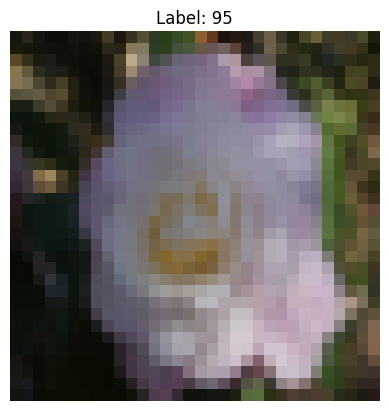

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# Get one batch from trainloader
dataiter = iter(trainloader)
images, labels, indices = next(dataiter)  # unpack your dataloader

# Select the first image from the batch
img_tensor = images[0]  # shape: [C, H, W]

# Convert tensor to PIL image
to_pil = transforms.ToPILImage()
pil_img = to_pil(img_tensor)

# (Optional) show inline if using Jupyter Notebook
plt.imshow(pil_img)
plt.title(f"Label: {labels[0]}")
plt.axis('off')
plt.show()